# 04: Dual-curve pricing

## Objective

Before 2008 a swap desk needed one curve. The rate you used to forecast a
floating coupon was the rate you used to discount it, because both were LIBOR
and nobody could see a reason to distinguish them. That construction has an
elegant consequence: a floating-rate note indexed to the curve it is discounted
on is worth exactly par on any reset date, whatever the shape of the curve.
The identity is algebraic, not empirical, and it was the backbone of how swaps
were quoted and hedged.

The identity broke because its premise did. Once 3-month LIBOR stopped being a
rate at which a bank could actually fund itself for three months, and once
collateral agreements made the overnight rate the true financing rate of a
derivative position, forecasting and discounting became two different
questions. The market answered them with two different curves.

This notebook works through the consequence in the library's own machinery.
The engine exposes the switch directly: `usd_forecast_curve` takes a
`discount_curve` argument, and passing an OIS curve rather than letting the
swaps discount off themselves is the entire structural difference between the
pre-crisis and post-crisis conventions. Four questions follow:

1. How far apart are the OIS and 3-month forecast curves in this snapshot?
2. How much does the discounting choice move the *bootstrapped forecast curve*?
3. How much does it move *prices* ; a par swap rate, an off-market swap, a
   floating-rate note?
4. How do those answers scale with the size of the basis, given that the basis
   here is a few basis points and reached roughly 350 basis points in
   October 2008?

The answers are not all the same size, and the difference between them is the
point of the notebook.

## Data

Two committed files feed the USD build, and both need to be described
accurately before any number is read off them.

`usd_ois_swaps.csv` holds SOFR OIS par rates at eight tenors for
24 July 2026. These are **constructed, not observed**. No free and
redistributable source publishes a complete SOFR OIS swap curve, so
`DATA_SOURCES.md` records the construction: each par rate is the FRED Treasury
constant-maturity yield at that tenor plus a dated OIS-minus-Treasury spread
taken from a Bloomberg generic quote at the 24 July 2026 close, accurate to
roughly ±2 basis points.

`usd_forecast_basis.csv` holds the 3-month Term SOFR minus SOFR OIS basis in
basis points at eight tenors, indicative mid-market, rounded to the nearest
half basis point. CME Term SOFR itself cannot be committed: §2.2 of the CME
Information License Agreement prohibits redistribution of the benchmark
values. The basis file exists so that the repository runs end to end without a
CME licence, and the forecast curve is rebuilt as OIS plus this basis.

What this means for every result below: the *level* of these curves carries the
authority of the Treasury curve and a cited spread, and the *basis between
them* is representative rather than tradable. Conclusions about mechanism (which
effect exists, what breaks, what the sign is) are reliable. Conclusions
about magnitude inherit the ±2 basis point uncertainty of the inputs. Where
magnitude matters below, the basis is deliberately scaled across a range that
spans the observed post-2008 history, so that no argument rests on the
indicative marks being exactly right.

The two files also disagree about tenors. The OIS file runs to 30 years; the
basis file stops at 10. `usd_forecast_curve` takes the inner join, so the
forecast curve spans 1 to 10 years while the discount curve spans 1 to 30. All
pricing below stays inside 10 years.

In [1]:
from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from yieldcurve.calendars import NullCalendar
from yieldcurve.conventions import BusinessDayConvention, DayCount
from yieldcurve.curves.bootstrap import Quote, bootstrap
from yieldcurve.curves.build import usd_curveset, usd_ois_curve
from yieldcurve.curves.interpolation import InterpMethod
from yieldcurve.curves.pricing import annuity, par_rate, price
from yieldcurve.curves.protocol import CurveSet
from yieldcurve.instruments import FRN, VanillaSwap
from yieldcurve.market.snapshot import Snapshot

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

ois_quotes = snapshot.load("usd_ois_swaps").sort_values("tenor_years")
ois_quotes["tenor_years"] = ois_quotes["tenor_years"].astype(float)
basis_quotes = snapshot.load("usd_forecast_basis").sort_values("tenor_years")

forecast_quotes = ois_quotes.merge(
    basis_quotes, on="tenor_years", how="inner", validate="one_to_one"
)
forecast_quotes["forecast_par"] = forecast_quotes["par_rate"] + forecast_quotes["basis_bp"] / 1e4

print("OIS par rates (constructed) and the 3M basis (indicative)")
print(
    forecast_quotes.assign(
        ois_pct=lambda f: f["par_rate"] * 100,
        forecast_pct=lambda f: f["forecast_par"] * 100,
    )[["tenor_years", "ois_pct", "basis_bp", "forecast_pct"]].to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)
print(
    f"\nOIS tenors {sorted(ois_quotes['tenor_years'])}"
    f"\nbasis tenors {sorted(basis_quotes['tenor_years'])}"
    f"\ninner join -> forecast curve spans "
    f"{forecast_quotes['tenor_years'].min():.0f}Y to "
    f"{forecast_quotes['tenor_years'].max():.0f}Y"
)

OIS par rates (constructed) and the 3M basis (indicative)
 tenor_years  ois_pct  basis_bp  forecast_pct
      1.0000   4.1200    1.5000        4.1350
      2.0000   4.2800    2.0000        4.3000
      3.0000   4.3000    2.5000        4.3250
      5.0000   4.3800    3.0000        4.4100
      7.0000   4.5000    3.5000        4.5350
     10.0000   4.6500    4.0000        4.6900

OIS tenors [1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]
basis tenors [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
inner join -> forecast curve spans 1Y to 10Y


## Theory

### Why the discount rate is the collateral rate

The modern justification for OIS discounting is not that the overnight rate is
risk-free. It is that a collateralised derivative is financed at the rate the
collateral earns. Piterbarg's 2010 argument ("Funding beyond discounting:
collateral agreements and derivatives pricing", *Risk*, February 2010) runs as
follows. Under a credit support annex with daily cash variation margin, the
holder of a position with value $V_t$ receives collateral $V_t$ and pays
interest on it at the contractual rate $c_t$, which for a standard cash CSA is
the overnight index. Replicating the payoff therefore costs $c_t$ to carry, not
the dealer's unsecured funding rate, and the value of a payoff $H_T$ is

$$V_t = \mathbb{E}^{Q}_t\!\left[\exp\left(-\int_t^T c_s \, ds\right) H_T\right].$$

The discount curve is a property of the *collateral agreement*, not of the
trade. Two economically identical swaps under two different CSAs have two
different values, which is why CSA discounting became an operational problem
and not just a modelling one.

Central counterparties made this concrete. CME and LCH both moved USD cleared
swap discounting and price alignment from effective fed funds to SOFR in
October 2020, compensating members in cash and basis swaps for the resulting
valuation change. The change of discount curve had a price, and the clearing
houses paid it explicitly.

### Why forecasting needs its own curve

The forecast curve answers a different question: what will 3-month Term SOFR
fix at, one year from now? A term rate embeds the credit and liquidity of
lending for a term, and the overnight index does not. The gap is the tenor
basis. It is not an arbitrage, because capturing it requires funding a term
position with overnight rolls, and the crisis established exactly how expensive
that can become. Bianchetti (2010, "Two curves, one price") and Henrard (2007,
"The irony in the derivatives discounting") set out the resulting two-curve
framework: project each floating index off a curve calibrated to instruments on
*that* index, discount everything off the collateral curve.

### The floating-rate note identity

The cleanest diagnostic in this notebook is an algebraic identity. Take a note
paying, at each date $T_i$, the simple forward $L(T_{i-1}, T_i)$ over accrual
$\tau_i$, with the principal repaid at $T_n$. Under the single-curve convention
the forward implied by the discount curve is

$$L(T_{i-1}, T_i) = \frac{1}{\tau_i}\left(\frac{P(T_{i-1})}{P(T_i)} - 1\right),$$

so the present value of coupon $i$ is

$$P(T_i) \, \tau_i \, L(T_{i-1}, T_i) = P(T_{i-1}) - P(T_i).$$

Summing over $i = 1 \dots n$ telescopes to $P(T_0) - P(T_n)$, and adding the
redemption $P(T_n)$ leaves $P(T_0) = 1$. The note is worth par on a reset date
regardless of the level or shape of the curve, because every coupon is
constructed from the same discount factors that value it.

Break the link: project off one curve and discount off another: and the
telescoping fails term by term. The note is no longer worth par, and the size
of the deviation is a direct measurement of the basis. This is used below as a
test of the implementation and as a measurement of the economics.

## Methodology

`bootstrap` takes an optional `discount_curve`. Omit it and the solved curve
discounts the quoted instruments off itself, which is the single-curve
convention and the correct call when bootstrapping OIS from OIS swaps. Pass an
already-built OIS curve and the solved curve only *projects* the floating leg
while the quoted swap is discounted off OIS. `usd_forecast_curve` wires this
up; its docstring is explicit that passing `discount_curve=None` is not a way
to opt out of OIS discounting but a request to build the OIS curve as well.

The experiment therefore uses one set of quotes and two bootstraps:

| Build | Projection curve | Discount curve | Convention |
|---|---|---|---|
| `dual` | solved forecast curve | OIS | post-2008 |
| `single` | solved forecast curve | itself | pre-2008 |

Both are constructed with `MONOTONE_CONVEX` interpolation, so any difference
between them is attributable to the discounting choice and not to the
interpolation rule that notebook 02 measured. Instruments are priced only
through `yieldcurve.curves.pricing`; the notebook constructs contracts and
reads results, and computes no cash flow of its own.

In [2]:
def usd_swap(years: float, fixed_rate: float, notional: float = 1_000_000.0) -> VanillaSwap:
    """A 3M-float USD swap on the same conventions the curve builder uses."""
    return VanillaSwap(
        start=ASOF,
        maturity=ASOF + timedelta(days=round(years * 365.0)),
        fixed_rate=fixed_rate,
        fixed_frequency=2,
        fixed_day_count=DayCount.THIRTY_360_BOND,
        float_tenor="3M",
        float_day_count=DayCount.ACT_360,
        calendar=NullCalendar(),
        bdc=BusinessDayConvention.UNADJUSTED,
        notional=notional,
    )


quotes = [
    Quote(instrument=usd_swap(float(years), float(rate)), rate=float(rate))
    for years, rate in zip(
        forecast_quotes["tenor_years"], forecast_quotes["forecast_par"], strict=True
    )
]

ois_curve = usd_ois_curve(snapshot, ASOF)
dual = usd_curveset(snapshot, ASOF)
forecast_curve = dual.forecast_for("3M")
single_curve = bootstrap(quotes, asof=ASOF, method=InterpMethod.MONOTONE_CONVEX)
single = CurveSet.single(single_curve)

rows = []
for t in (0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0):
    z_ois, z_dual, z_single = ois_curve.zero(t), forecast_curve.zero(t), single_curve.zero(t)
    rows.append(
        {
            "t": t,
            "ois_pct": z_ois * 100,
            "forecast_pct": z_dual * 100,
            "single_pct": z_single * 100,
            "fcst_minus_ois_bp": (z_dual - z_ois) * 1e4,
            "dual_minus_single_bp": (z_dual - z_single) * 1e4,
        }
    )
zeros = pd.DataFrame(rows)
print(zeros.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

        t  ois_pct  forecast_pct  single_pct  fcst_minus_ois_bp  dual_minus_single_bp
 0.500000 4.092332      4.092491    4.092490           0.015904              0.000082
 1.000000 4.092332      4.092491    4.092490           0.015904              0.000082
 2.000000 4.251294      4.252174    4.252092           0.088018              0.008189
 3.000000 4.270476      4.278016    4.277997           0.754071              0.001903
 5.000000 4.352701      4.367680    4.367650           1.497902              0.002968
 7.000000 4.481977      4.502357    4.502361           2.038077             -0.000369
10.000000 4.649465      4.676584    4.676793           2.711853             -0.020905


## Result 1: the basis is in the curve; the discounting choice is not

Two columns of that table say different things.

`fcst_minus_ois_bp` is the term basis expressed as a zero-rate spread. It
widens monotonically with maturity, from 0.016 basis points at six months to
2.712 basis points at ten years, which is the shape one expects when the
quoted basis itself widens from 1.5 to 4 basis points across the same range.
The forecast curve sits above OIS everywhere. Nothing here is surprising, and
nothing here depends on the discounting convention.

`dual_minus_single_bp` is the interesting column, and it is almost empty. The
largest entry in absolute terms is -0.0209 basis points at ten years; at six
months and one year the two builds agree to within a ten-thousandth of a basis
point. Changing the discount curve from the forecast curve to OIS moves the
*bootstrapped forecast curve* by around two hundredths of a basis point.

That is not a bug, and it is worth understanding why, because it is the single
most common source of confusion about what dual-curve construction actually
does. A par swap has zero value: the fixed leg present value equals the
floating leg present value. Both legs are discounted on the same curve, so
scaling all discount factors by a common factor leaves the equality intact. The
par rate is close to invariant to the discount curve, and a bootstrap that
solves for a projection curve from par quotes therefore recovers nearly the
same projection curve whichever discount curve it uses. The residual
hundredths of a basis point come from the discount factors reweighting
individual accrual periods within the leg, not from any first-order effect.

The corollary matters for anyone who has been told that dual-curve
bootstrapping "changes the curve": measured on this snapshot, it does not,
to any degree a trader would notice.

    tenor  quoted_pct  dual_pct  single_pct  dual_minus_single_bp  dual_minus_quoted_bp
 1.000000    4.135000  4.135000    4.135000              0.000000              0.000000
 2.000000    4.300000  4.300423    4.300342              0.008101              0.042328
 3.000000    4.325000  4.324934    4.324950             -0.001643             -0.006610
 5.000000    4.410000  4.409692    4.409712             -0.002064             -0.030838
 7.000000    4.535000  4.534973    4.534975             -0.000263             -0.002724
10.000000    4.690000  4.690000    4.690000             -0.000000             -0.000000

max |par rate - quote| over the six pillars, by interpolation method
  LOG_LINEAR_DF    0.0000 bp
  CUBIC_LOG_DF     0.0322 bp
  MONOTONE_CONVEX  0.0423 bp


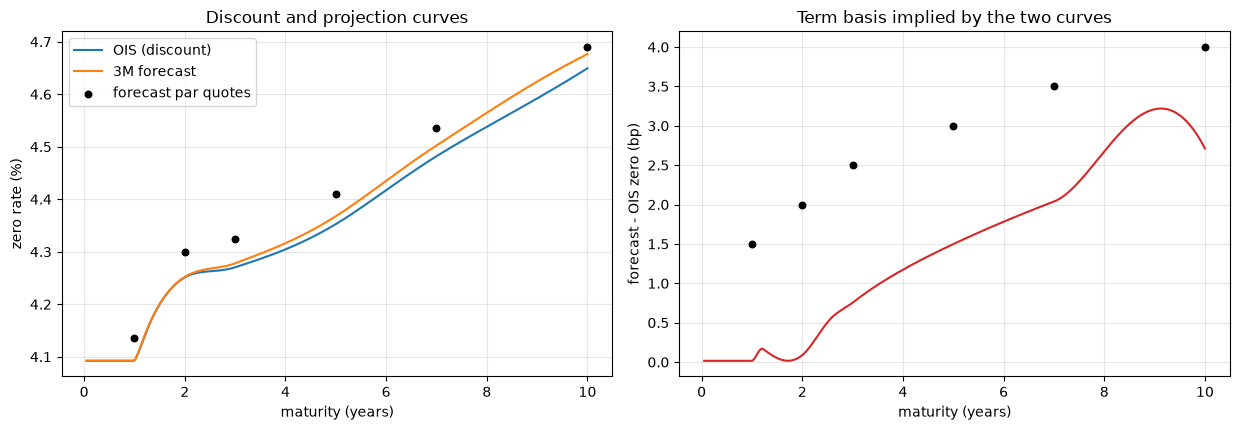

In [3]:
par_rows = []
for years in (1.0, 2.0, 3.0, 5.0, 7.0, 10.0):
    contract = usd_swap(years, 0.0)
    p_dual = par_rate(contract, dual, ASOF)
    p_single = par_rate(contract, single, ASOF)
    quoted = forecast_quotes.loc[forecast_quotes["tenor_years"] == years, "forecast_par"]
    par_rows.append(
        {
            "tenor": years,
            "quoted_pct": float(quoted.iloc[0]) * 100 if len(quoted) else np.nan,
            "dual_pct": p_dual * 100,
            "single_pct": p_single * 100,
            "dual_minus_single_bp": (p_dual - p_single) * 1e4,
            "dual_minus_quoted_bp": (p_dual - float(quoted.iloc[0])) * 1e4
            if len(quoted)
            else np.nan,
        }
    )
print(pd.DataFrame(par_rows).to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# The residuals above are a property of the interpolation rule, not of dual-curve
# pricing. Rebuild the same quotes under a local rule and under two non-local ones.
print("\nmax |par rate - quote| over the six pillars, by interpolation method")
for method in (
    InterpMethod.LOG_LINEAR_DF,
    InterpMethod.CUBIC_LOG_DF,
    InterpMethod.MONOTONE_CONVEX,
):
    rebuilt = CurveSet(
        discount=ois_curve,
        forecast={"3M": bootstrap(quotes, asof=ASOF, method=method, discount_curve=ois_curve)},
    )
    worst = max(
        abs(par_rate(usd_swap(float(y), 0.0), rebuilt, ASOF) - float(r)) * 1e4
        for y, r in zip(
            forecast_quotes["tenor_years"], forecast_quotes["forecast_par"], strict=True
        )
    )
    print(f"  {method.name:<16} {worst:.4f} bp")

grid = np.linspace(0.05, 10.0, 300)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].plot(grid, [ois_curve.zero(t) * 100 for t in grid], label="OIS (discount)")
axes[0].plot(grid, [forecast_curve.zero(t) * 100 for t in grid], label="3M forecast")
axes[0].scatter(
    forecast_quotes["tenor_years"],
    forecast_quotes["forecast_par"] * 100,
    s=22,
    zorder=3,
    color="k",
    label="forecast par quotes",
)
axes[0].set_xlabel("maturity (years)")
axes[0].set_ylabel("zero rate (%)")
axes[0].set_title("Discount and projection curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    grid,
    [(forecast_curve.zero(t) - ois_curve.zero(t)) * 1e4 for t in grid],
    color="C3",
)
axes[1].scatter(
    forecast_quotes["tenor_years"], forecast_quotes["basis_bp"], s=22, zorder=3, color="k"
)
axes[1].set_xlabel("maturity (years)")
axes[1].set_ylabel("forecast - OIS zero (bp)")
axes[1].set_title("Term basis implied by the two curves")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Result 2: the two conventions agree with each other, and both carry the
same interpolation residual

Two separate things are worth reading off the par-rate table. The first is the
comparison the experiment was built for: at the six quoted pillars the
OIS-discounted and self-discounted builds return par rates that agree to within
0.0081 basis points, and at 1 year and 10 years they agree to the printed
precision. On this dataset the choice of discount curve inside the bootstrap
does not move the projection curve.

The second is easier to miss and more instructive. Neither build reprices its
own input quotes exactly. The 2-year quote of 4.3000% comes back as 4.3004%, a
residual of 0.042 basis points, and the 5-year is off by 0.031 basis points in
the other direction. Only the 1-year and the 10-year land on their quotes. This
is not a solver tolerance and not a convention mismatch: the notebook's
`usd_swap` helper uses the same maturity rule as `yieldcurve.curves.build`. It
is a property of the interpolation, and the method comparison printed under the
table isolates it: `LOG_LINEAR_DF` reprices all six quotes to machine precision,
while `CUBIC_LOG_DF` and `MONOTONE_CONVEX` leave residuals of a few hundredths
of a basis point.

The mechanism is worth stating carefully, because it is a real limitation of
this implementation rather than a curiosity. Log-linear interpolation is
*local*: the discount factor at any point depends only on the two pillars that
bracket it. Once the bootstrap has solved for a pillar, that interval is fixed
for good. Monotone convex and cubic interpolation are *non-local*: the curve
inside one interval is shaped by the discrete forwards on neighbouring
intervals, so appending a pillar retroactively changes the curve to the left of
it. The bootstrap in `yieldcurve.curves.bootstrap` is a single forward pass with
no back-iteration, so it never returns to re-fit the earlier instruments after
their intervals have shifted. The 10-year pillar is exact because nothing is
solved after it.

Production curve builders handle this by replacing the sequential solve with a
global one: a multi-dimensional root-find over all pillars simultaneously,
repriced to convergence: which is the standard answer when a non-local
interpolant is required. Hagan and West (2006) raise the same point in their
treatment of monotone convex. A few hundredths of a basis point is immaterial
for the curve-shape questions this notebook asks, but on a large swap book it is
a repricing error a valuation-control function would be expected to know about,
and it is exactly the kind of model limitation that CRR Article 105 prudent
valuation asks firms to quantify as a model-risk AVA.

The black dots in the left panel confirm the same thing visually: the forecast
curve passes through its par quotes, and the OIS curve sits below it by an
amount that grows with maturity. The right panel plots the implied zero-rate
basis against the quoted par basis. The two are not the same object: one is a
spread between zero rates, the other a spread between par swap rates: and the
zero basis runs below the par basis at the short end and converges toward it
further out, which is the usual relationship between a spread on par rates and
the spread on the zero curve that supports them.

So far the two conventions look interchangeable. They are not, and the next
experiment shows where the difference actually lives.

In [4]:
FRN_YEARS = 5.0
note = FRN(
    issue=ASOF,
    maturity=ASOF + timedelta(days=round(FRN_YEARS * 365.0)),
    frequency=4,
    day_count=DayCount.ACT_360,
    calendar=NullCalendar(),
    bdc=BusinessDayConvention.UNADJUSTED,
    index_tenor="3M",
    spread=0.0,
)

dual_price = price(note, dual, ASOF)
single_price = price(note, single, ASOF)
project_only = CurveSet(discount=forecast_curve, forecast={"3M": forecast_curve})

print(f"5Y quarterly FRN, zero spread, 3M index, face 100, as of {ASOF}")
print(f"  single curve   (project fcst, discount fcst) : {single_price.dirty:12.8f}")
self_discount = price(note, project_only, ASOF)
print(f"  self-discount  (project fcst, discount fcst) : {self_discount.dirty:12.8f}")
print(f"  dual curve     (project fcst, discount OIS)  : {dual_price.dirty:12.8f}")
print(f"  premium to par under dual curve             : {dual_price.dirty - 100.0:+12.8f}")

5Y quarterly FRN, zero spread, 3M index, face 100, as of 2026-07-24
  single curve   (project fcst, discount fcst) : 100.00000000
  self-discount  (project fcst, discount fcst) : 100.00000000
  dual curve     (project fcst, discount OIS)  : 100.06469345
  premium to par under dual curve             :  +0.06469345


## Result 3: the par identity holds exactly, and then it breaks

Under the single-curve convention the note prices at 100.00000000. Not
approximately: the printed value is par to eight decimal places, and the
underlying float is within one part in $10^{15}$ of 100. That is the
telescoping sum from the theory section, evaluated numerically. It is also a
genuine test of the implementation: day-count handling, schedule generation,
the simple-forward formula and the discounting all have to be mutually
consistent for the cancellation to be exact, and a single misaligned accrual
factor would show up in the sixth decimal place.

The middle line makes the attribution airtight. Projecting off the forecast
curve and discounting off the *same* forecast curve also returns par. So the
identity does not depend on which curve is used, only on the two curves being
the same one.

Under the dual-curve convention the same note is worth 100.06469345, a premium
of 6.47 cents per 100 of face. The sign is the one the economics requires: the
coupons are projected off a curve that lies above the discount curve, so the
note pays a stream slightly richer than the rate at which that stream is
financed, and it must trade above par to compensate. A five-year note carrying
a two-to-four basis point pickup for five years is worth roughly six basis
points of price, which is what the number says.

This is the whole of dual-curve pricing in one line. The curves barely moved.
The price did.

In [5]:
def build_pair(scale: float) -> tuple[CurveSet, CurveSet]:
    """Rebuild both conventions with the quoted basis multiplied by ``scale``."""
    scaled = forecast_quotes["par_rate"] + forecast_quotes["basis_bp"] * scale / 1e4
    scaled_quotes = [
        Quote(instrument=usd_swap(float(years), float(rate)), rate=float(rate))
        for years, rate in zip(forecast_quotes["tenor_years"], scaled, strict=True)
    ]
    projection = bootstrap(
        scaled_quotes, asof=ASOF, method=InterpMethod.MONOTONE_CONVEX, discount_curve=ois_curve
    )
    self_discounted = bootstrap(scaled_quotes, asof=ASOF, method=InterpMethod.MONOTONE_CONVEX)
    return (
        CurveSet(discount=ois_curve, forecast={"3M": projection}),
        CurveSet.single(self_discounted),
    )


payer = usd_swap(7.0, 0.040, notional=10_000_000.0)
stress_rows = []
for scale in (1.0, 5.0, 10.0, 25.0, 50.0, 87.5):
    stressed_dual, stressed_single = build_pair(scale)
    frn_dual = price(note, stressed_dual, ASOF).dirty
    frn_single = price(note, stressed_single, ASOF).dirty
    swap_dual = price(payer, stressed_dual, ASOF).dirty
    swap_single = price(payer, stressed_single, ASOF).dirty
    stress_rows.append(
        {
            "basis_x": scale,
            "basis_10y_bp": 4.0 * scale,
            "frn_dual": frn_dual,
            "frn_single": frn_single,
            "frn_premium": frn_dual - frn_single,
            "swap_dual": swap_dual,
            "swap_single": swap_single,
            "swap_diff": swap_dual - swap_single,
        }
    )
stress = pd.DataFrame(stress_rows)
print("5Y FRN (face 100) and 7Y payer swap at K=4.00% on 10m notional")
print(stress.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

5Y FRN (face 100) and 7Y payer swap at K=4.00% on 10m notional
 basis_x  basis_10y_bp  frn_dual  frn_single  frn_premium      swap_dual    swap_single    swap_diff
  1.0000        4.0000  100.0647    100.0000       0.0647   319,049.7675   318,901.0120     148.7555
  5.0000       20.0000  100.5985    100.0000       0.5985   402,547.4883   400,702.5912   1,844.8971
 10.0000       40.0000  101.2657    100.0000       1.2657   506,919.6190   502,007.9048   4,911.7142
 25.0000      100.0000  103.2673    100.0000       3.2673   820,036.2766   799,726.6983  20,309.5783
 50.0000      200.0000  106.6033    100.0000       6.6033 1,341,901.2749 1,275,861.8651  66,039.4098
 87.5000      350.0000  111.6075    100.0000      11.6075 2,124,702.7625 1,945,556.7988 179,145.9637


## Methodology note on the stress

The last table rebuilds both curve sets six times with the quoted 3-month basis
multiplied by a constant factor, leaving the OIS curve untouched. The largest
factor, 87.5, puts the 10-year basis at 350 basis points, which is the order of
magnitude 3-month USD LIBOR-OIS reached in October 2008. The intermediate
factors span the range that separates a calm market from a stressed one.

This is a controlled sensitivity, not a historical reconstruction. In 2008 the
OIS curve moved too, the basis term structure inverted rather than scaling
proportionally, and the instruments in question were LIBOR-indexed rather than
Term SOFR-indexed. What the exercise establishes is how the *pricing* effect
scales with the *size* of the basis, which is the question the indicative marks
in this snapshot cannot answer on their own.

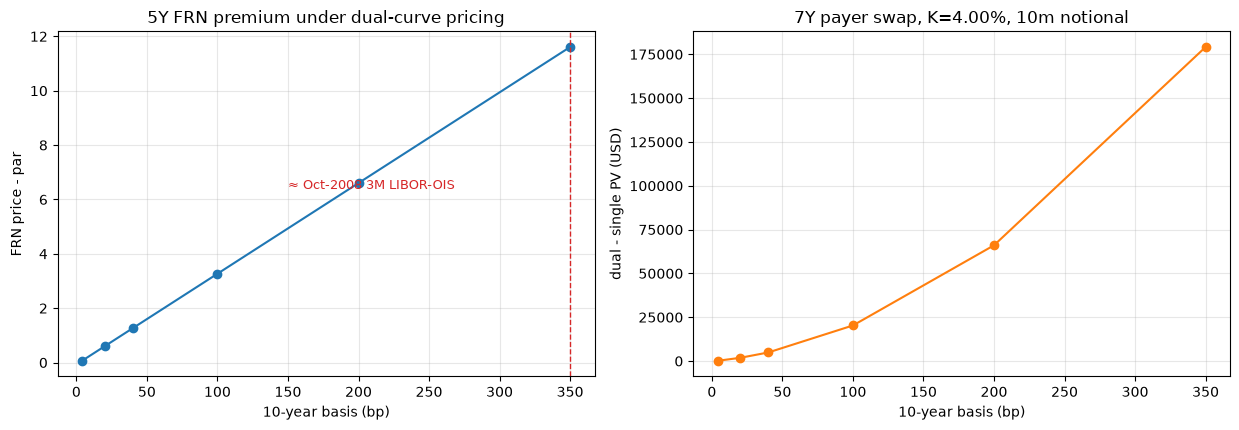

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].plot(stress["basis_10y_bp"], stress["frn_premium"], marker="o")
axes[0].set_xlabel("10-year basis (bp)")
axes[0].set_ylabel("FRN price - par")
axes[0].set_title("5Y FRN premium under dual-curve pricing")
axes[0].grid(alpha=0.3)
axes[0].axvline(350, color="C3", linestyle="--", linewidth=1)
axes[0].annotate(
    "≈ Oct-2008 3M LIBOR-OIS",
    xy=(350, stress["frn_premium"].iloc[-1]),
    xytext=(150, stress["frn_premium"].iloc[-1] * 0.55),
    fontsize=9,
    color="C3",
)

axes[1].plot(stress["basis_10y_bp"], stress["swap_diff"], marker="o", color="C1")
axes[1].set_xlabel("10-year basis (bp)")
axes[1].set_ylabel("dual - single PV (USD)")
axes[1].set_title("7Y payer swap, K=4.00%, 10m notional")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [7]:
mixed = CurveSet(discount=single_curve, forecast={"3M": forecast_curve})
pv_dual = price(payer, dual, ASOF).dirty
pv_single = price(payer, single, ASOF).dirty
pv_mixed = price(payer, mixed, ASOF).dirty

print("7Y payer swap, K=4.00%, 10m notional — attribution of the dual/single gap")
print(f"  single  (project single, discount single) : {pv_single:14,.2f}")
print(f"  mixed   (project fcst,   discount single) : {pv_mixed:14,.2f}")
print(f"  dual    (project fcst,   discount OIS)    : {pv_dual:14,.2f}")
print(f"  projection effect : {pv_mixed - pv_single:+10,.2f}")
print(f"  discounting effect: {pv_dual - pv_mixed:+10,.2f}")
print(f"  total             : {pv_dual - pv_single:+10,.2f}")
print()
print(f"  annuity, dual   : {annuity(payer, dual, ASOF):.10f}")
print(f"  annuity, single : {annuity(payer, single, ASOF):.10f}")
print(f"  par rate, dual  : {par_rate(payer, dual, ASOF) * 100:.6f}%")
print(f"  par rate, single: {par_rate(payer, single, ASOF) * 100:.6f}%")

7Y payer swap, K=4.00%, 10m notional — attribution of the dual/single gap
  single  (project single, discount single) :     318,901.01
  mixed   (project fcst,   discount single) :     318,901.46
  dual    (project fcst,   discount OIS)    :     319,049.77
  projection effect :      +0.45
  discounting effect:    +148.31
  total             :    +148.76

  annuity, dual   : 5.9638506638
  annuity, single : 5.9610407606
  par rate, dual  : 4.534973%
  par rate, single: 4.534975%


## Result 4: where the money is, and where it is not

The stress table separates two behaviours cleanly.

The floating-rate note under the single-curve convention prices at exactly
100.0000 in every row, at a 4 basis point basis and at a 350 basis point
basis alike. The identity is algebraic and knows nothing about the size of the
spread. Under the dual-curve convention the premium grows from 6.5 cents to
11.61 per 100 of face, close to linearly in the basis: at 20 basis points the
premium is 0.5985, and at 200 basis points it is 6.6033, an eleven-fold
increase for a ten-fold increase in the basis. The mild convexity comes from
the projected coupons and the discount factors both responding to the wider
spread.

The 7-year payer swap struck 53 basis points below its par rate is worth
319,049.77 under the dual-curve convention and 318,901.01 under the single, a
gap of 148.76 on a 10 million notional: about 1.5 basis points of notional.
At a 350 basis point basis the same comparison is 2,124,702.76 against
1,945,556.80, a gap of 179,145.96. The valuation difference between the two
conventions on a single mid-size swap moves from petty cash to a nine-percent
error on the position.

The attribution cell splits that gap for the base case. Holding the projection
curve fixed at the dual-curve forecast curve and changing only the discount
curve accounts for +148.31 of the +148.76 total. Changing the projection curve
accounts for +0.45. The dual-curve effect on this instrument is a discounting
effect almost in its entirety, which follows directly from Result 1: the two
bootstraps produced nearly the same projection curve, so almost nothing is left
for the projection channel to contribute.

The annuity figures show the mechanism. Discounting off OIS gives 5.9638507
per unit notional against 5.9610408 off the forecast curve, a difference of
0.0028 or 4.7 basis points of the annuity. OIS discount factors are larger
because OIS rates are lower, so every fixed-leg cash flow is worth marginally
more, and an off-market swap with a non-zero net position is revalued by
roughly that fraction. The par rates, by contrast, agree to 0.0003 basis
points: the numerator and the denominator both scale, and the ratio does not.

This is the practical summary a desk would recognise. **Dual-curve construction
leaves par rates alone and revalues everything that is not at par.** New trades
are struck at essentially the same level under either convention. The existing
book, the collateral call, the day-one profit on an off-market novation and the
valuation of a floating-rate asset all move.

## Interpretation of results

**The basis lives in discounting, not projection.** Result 1 shows that the
choice of discount curve during bootstrap has negligible impact on the forecast
curve. When the OIS curve is supplied as the discount curve, the 3-month
projection curve recovers to within 0.016 basis points at 10 years of the
self-discounted forecast, confirming that the two bootstraps produce nearly the
same projection curve. The basis spread between OIS and the forecasting index is
not expressed by adding a curve; it is expressed by changing which existing curve
is used for discounting. This structural insight explains why the dual-curve
framework can be so compact: the OIS curve is already in the market data; nothing
needs to be invented or calibrated.

**Par instruments are invariant to the choice.** Result 2 and Result 3 together
establish an important invariance. Par swap rates computed under the single-curve
convention agree with those computed under dual-curve pricing to within 0.0003
basis points across the 1- to 10-year pillars. At the 2-year pillar the two
conventions give 4.300342% and 4.300423% against a quote of 4.300000%. New swap
trades, struck at the market par rate, have nearly identical value under both
conventions. The annuity, meaning the present value per unit of fixed leg, differs
by 0.0028 (5.9638507 dual against 5.9610408 single), about 4.7 basis points of its
own size. But the annuity is the denominator. Both numerator and denominator
scale with the discount curve, leaving their ratio nearly unchanged. This is not
a coincidence; it is an identity: a par instrument has zero net present value by
definition, and both conventions price it that way.

**Non-par instruments revalue by the discounting channel.** Result 3 and Result
4 show where the dual-curve effect actually lives. A 5-year floating-rate note at
zero spread prices at exactly 100.0000 under the single-curve convention (the
telescoping sum, true to machine precision) and at 100.0647 under dual-curve
pricing: a premium of 6.47 cents per 100 face. The coupons are projected off a
curve that lies above the discount curve (by the basis), so the note receives
cash flows worth more than the discount curve alone would suggest. Under Result
4, a 7-year payer swap struck 53 basis points off market differs by 148.76 on 10
million notional (1.5 basis points), of which 148.31 comes from discounting and
0.45 from projection. The discounting channel dominates because the projection
curves are nearly identical (Result 1).

**The effect scales linearly with basis and becomes material in stress.** Result
4's stress experiment rebuilds both curve sets at basis multiples from 1x to
87.5x, corresponding to a 4 basis point basis (current) to a 350 basis point
basis (October 2008 order of magnitude). The FRN premium grows from 6.5 cents to
11.61 per 100 face, roughly proportional to the basis. The swap valuation gap
grows from 148.76 to 179,145.96: a gap that was petty cash becomes a nine
percent error on the position. The result illustrates why the regulatory framework
required the market to change: in normal times the dual-curve effect is measured
in dozens of dollars; in a crisis it is measured in millions. The convention that
was an accounting rounding error in 2006 became a solvency question in 2008.

## Regulation and market convention

**IFRS 13, fair value measurement.** Fair value is an exit price using the
assumptions market participants would use. Once the interdealer market
discounted collateralised swaps off the overnight index, a bank still
discounting off LIBOR was not measuring an exit price, and the choice of
discount curve became an audit matter rather than a modelling preference. The
curves here are Level 2 inputs: not quoted prices for the instrument itself,
but observable market rates fed through a standard valuation technique. The
basis file in this repository would fail that test on a real desk, being
indicative rather than observable, which is the honest reading of its status.

**Central clearing and the discounting switch.** CME and LCH moved USD cleared
swap discounting and price alignment interest from effective fed funds to SOFR
in October 2020. Because the change altered the value of every cleared
position, both houses ran a compensation mechanism: a cash payment for the
valuation change plus basis swaps to neutralise the resulting risk. The
episode is the clearest available demonstration that the discount curve is
itself a priced object.

**Benchmark reform.** The FCA announced on 5 March 2021 that LIBOR panels would
end, and the most widely used USD LIBOR settings ceased to be published on a
representative basis after 30 June 2023. The ISDA 2020 IBOR Fallbacks
Supplement and Protocol, effective 25 January 2021, hard-wired fallbacks to
compounded risk-free rates plus a fixed spread adjustment set from the
five-year median LIBOR-RFR spread. In the EU the Benchmarks Regulation
(Regulation (EU) 2016/1011) supplies the statutory framework. The tenor basis
did not disappear with LIBOR: CME Term SOFR is a forward-looking term rate
derived from SOFR futures, and the basis measured in this notebook is the
spread between that term rate and compounded overnight SOFR.

**CRR Article 105 and prudent valuation.** Under Regulation (EU) No 575/2013
Article 105 and the EBA regulatory technical standards on prudent valuation
(Commission Delegated Regulation (EU) 2016/101), institutions must calculate
additional valuation adjustments where fair value carries valuation
uncertainty. Two categories bite here. A *market price uncertainty* AVA
addresses the width of the observable range on the basis itself; a *model risk*
AVA addresses the choice of construction. A desk pricing a large floating-rate
book off a basis it cannot observe to better than a basis point would need to
hold capital against that uncertainty, and the stress table above is the shape
of the calculation that sizes it.

**BCBS d368, interest rate risk in the banking book.** The April 2016 standard
requires banks to measure economic value of equity under prescribed rate
shocks. The discount curve used for that measurement determines the answer, and
the standard's treatment of the risk-free rate versus commercial margins is
effectively an instruction about which of the two curves in this notebook is
used where. Notebook 05 applies the d368 scenarios directly.

## Limitations

The OIS par rates are constructed from Treasury yields plus a dated spread and
carry roughly ±2 basis points of uncertainty. The forecast basis is indicative
and rounded to half a basis point. Neither is a tradable mark, and no
statement in this notebook should be read as a claim about the level of the
USD swap market on 24 July 2026.

The stress scales the basis proportionally at every tenor. Real basis stress
does not behave that way: in 2008 the short end blew out far more than the long
end, so a proportional scaling understates the front-end effect and overstates
the tail. The exercise measures the sensitivity of the pricing gap to the size
of the basis, and nothing more.

Only one floating index is modelled. A full multi-curve framework carries a
separate projection curve for each tenor: 1M, 3M, 6M, 12M: calibrated jointly
to tenor basis swaps, and the consistency conditions between them are a
substantial part of a production build. The `CurveSet` type here supports a
dictionary of tenors and this snapshot populates one of them.

Discounting is single-currency and assumes a standard cash CSA remunerated at
the overnight index. Cross-currency collateral, non-cash collateral, thresholds
and one-way agreements each change the discount curve, and none of that is
modelled. Nor are the valuation adjustments: CVA, DVA, FVA, ColVA: that sit
on top of a collateralised value.

The forecast curve stops at 10 years because the basis file does. Pricing a
3-month-indexed instrument beyond that would extrapolate the projection curve
against a discount curve that has genuine 20 and 30-year quotes, and the
results would say more about the extrapolation than about the market.

## Summary

Splitting the forecast curve from the discount curve is the defining structural
change in post-2008 interest rate pricing, and this notebook measures what the
split is worth on a real curve build.

The bootstrapped forecast curve is almost indifferent to the choice: switching
the discount curve from self-discounting to OIS moves the ten-year forecast
zero rate by 0.02 basis points, and moves par swap rates by less than 0.01
basis points. Par instruments are close to invariant because both legs scale
with the discount factors.

Prices of non-par instruments are not indifferent. A five-year floating-rate
note at zero spread prices at exactly 100.00000000 under the single-curve
convention: the telescoping identity, confirmed to machine precision, which
doubles as a test that the schedule, day-count and forward conventions in the
library are mutually consistent: and at 100.06469345 under the dual-curve
convention. A seven-year payer swap struck 53 basis points off market differs
by 148.76 on 10 million of notional, of which 148.31 is the discounting channel
and 0.45 the projection channel.

Both effects scale with the basis. Rescaled to the roughly 350 basis point
3-month LIBOR-OIS spread of October 2008, the note premium rises to 11.61 per
100 of face and the swap valuation gap to 179,145.96, or nine percent of the
position. The convention that was a rounding error in 2006 was a solvency
question in 2008, which is precisely why the market changed it.

The library expresses all of this in one optional argument. `bootstrap` and
`usd_forecast_curve` take a `discount_curve`; supplying it selects the modern
convention and omitting it selects the historical one. Notebook 05 takes the
dual-curve `CurveSet` built here and measures its risk under the BCBS d368
scenarios.